In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

mpl.rcParams['image.cmap'] = 'bwr'

from skimage.transform import resize
from src import *

In [3]:
def get_01_rhat(h, hatPyi):
    return lambda x: 1 - np.where(h(x), hatPyi[x], 1 - hatPyi[x]).prod()

def get_avg_msp_rhat(h, hatPyi):
    return lambda x: 1 - np.where(h(x), hatPyi[x], 1 - hatPyi[x]).mean()

def get_softvoldiff(h, hatPyi):
    return lambda x: np.abs(hatPyi[x].sum(dtype=float) - h(x).sum(dtype=float)) / (h(x).shape[0] * h(x).shape[1])

def get_quadvoldiff_rhat(h, hatPyi):
    def r_hat(x):
        y_hat = h(x).flatten()
        p_hat = hatPyi[x].flatten()
        
        return (np.sum(y_hat - p_hat)**2 + np.sum(p_hat - p_hat**2)) / (h(x).shape[0] * h(x).shape[1])

    return r_hat

def get_softdice_risk(h, hatPyi):
    return lambda x: 1 - 2 * np.sum(hatPyi[x] * h(x)) / (hatPyi[x].sum() + h(x).sum())

def plot_rc_curve(ax, r_hat, errors, name, ideal_aurc=None, random_aurc=None):
    risks, coverages = rc_curve_(errors, -np.array([r_hat(x) for x in range(len(errors))]))

    aurc = auc(coverages, risks)

    if ideal_aurc is not None:
        aurc = (aurc - ideal_aurc)
        if random_aurc is not None:
            aurc = aurc / (random_aurc - ideal_aurc)

    ax.plot(coverages, risks, label=name + f"({aurc:.4f})")

In [11]:
isic_val = np.load("/data/isic_unext_model/val/isic_unext_val.npz")

Y_og = isic_val["y"]
hatY_og = isic_val["y_hat"]

Y_og.shape, hatY_og.shape

((539, 1, 512, 512), (539, 1, 512, 512))

# Experiment 5

Our target space derives from a downsampled version of ISIC. Similarly, the model is the downsampled prediction of a SotA deep learning model (UNext).

## 32²

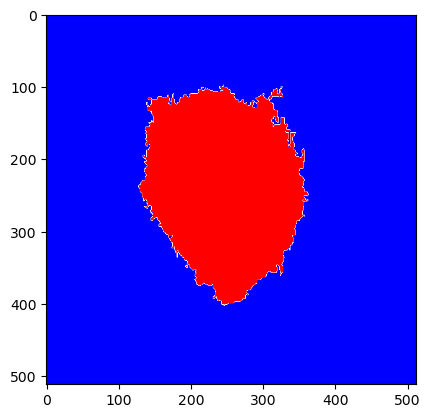

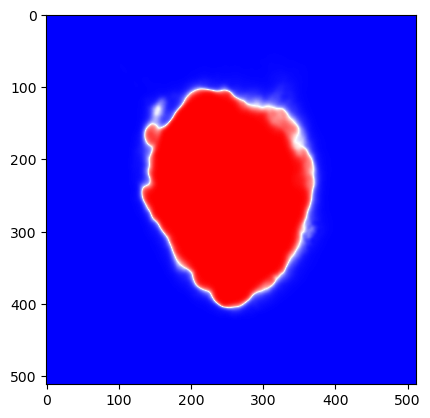

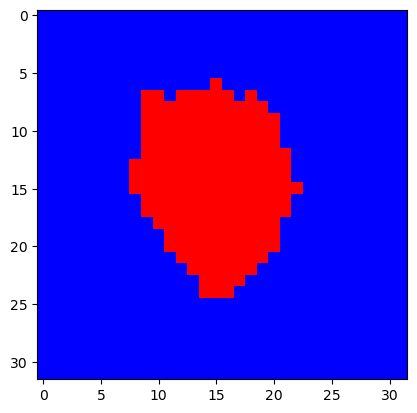

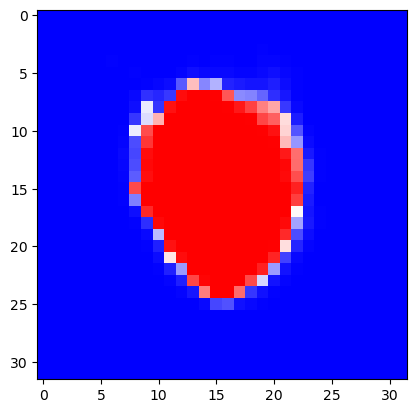

In [5]:
i = np.random.choice(Y_og.shape[0])
y = Y_og[i,0]
y_hat = hatY_og[i,0]

plt.imshow(y)
plt.show()

plt.imshow(y_hat)
plt.show()

y_small = resize(y, (32,32), order=0, anti_aliasing=False)
y_hat_small = resize(y_hat, (32,32), order=0, anti_aliasing=False)
plt.imshow(y_small)
plt.show()
plt.imshow(y_hat_small)
plt.show()

0.1955718994140625


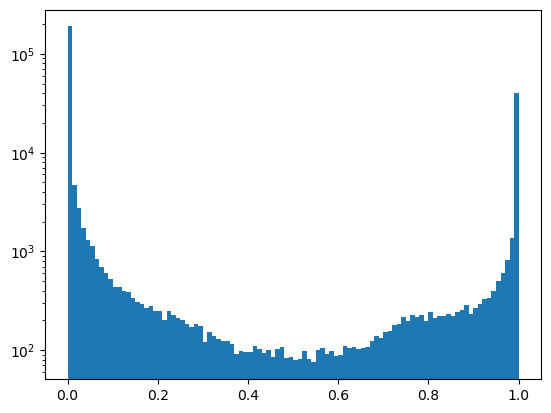

0.1953125


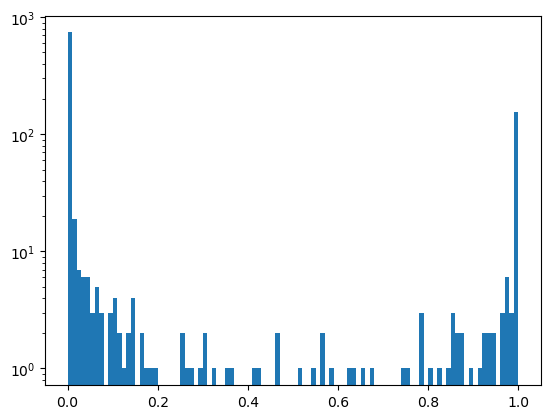

In [6]:
print(sum(y_hat.flatten() > 0.5) / (512*512))
plt.hist(y_hat.flatten(), bins=100)
plt.yscale('log')
plt.show()

print(sum(y_hat_small.flatten() > 0.5) / (32*32))
plt.hist(y_hat_small.flatten(), bins=100)
plt.yscale('log')
plt.show()

In [7]:
Y = [resize(y[0], (32,32), order=0, anti_aliasing=False) for y in Y_og]
hatY = [resize(y_hat[0], (32,32), order=0, anti_aliasing=False) for y_hat in hatY_og]

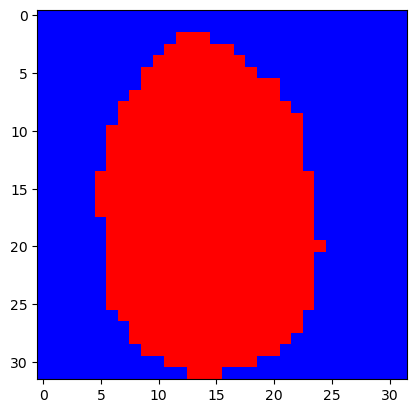

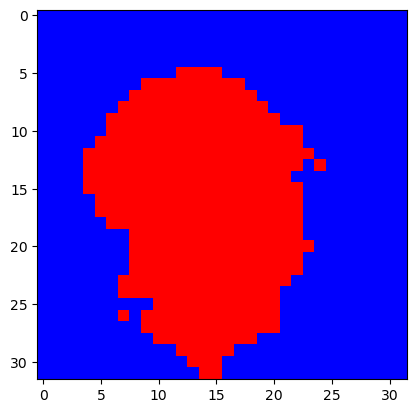

In [8]:
i = np.random.choice(len(Y))
y = Y[i]
y_hat = hatY[i]

plt.imshow(y)
plt.show()
plt.imshow(y_hat>0.5)
plt.show()

In [9]:
dummy_Py = np.eye(len(Y))
dummy_Pyi = Y
dummy_hatPyi = hatY

h = lambda x: hatY[x] > 0.5

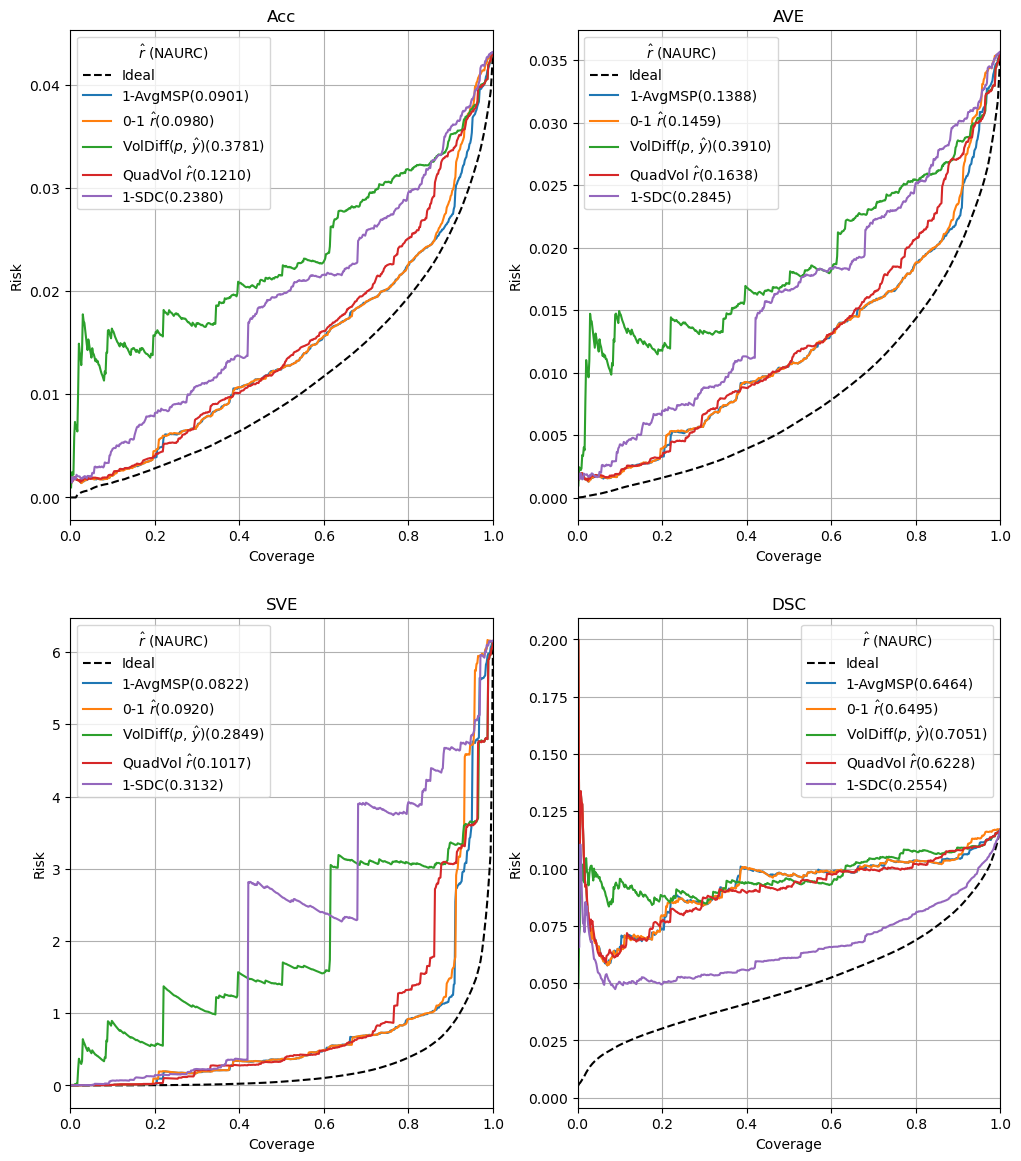

In [10]:
losses = {
    "Acc": lambda y, y_hat: 1 - (y == (y_hat > 0.5)).mean(),
    "AVE": lambda y, y_hat: np.abs(y.sum(dtype=float) - y_hat.sum(dtype=float)) / (y.shape[0] * y.shape[1]),
    "SVE": lambda y, y_hat: (y.sum(dtype=float) - y_hat.sum(dtype=float))**2 / (y.shape[0] * y.shape[1]),
    "DSC": lambda y, y_hat: 1 - 2 * (y * y_hat).sum() / (y.sum() + y_hat.sum()+1e-3)
}

fig, axs = plt.subplots(int(len(losses)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(losses)/2 + 0.5))

for ax, (loss_name, loss_fn) in zip(axs.flatten(), losses.items()):
    loss_values = np.array([loss_fn(y, y_hat) for y, y_hat in zip(Y, hatY)])

    ## IDEAL
    risks, coverages = rc_curve_(loss_values, -loss_values)
    ax.plot(coverages, risks, '--', c='black', label="Ideal")

    ideal_aurc = auc(coverages, risks)
    random_aurc = np.max(risks)

    ## MSP
    plot_rc_curve(ax, get_avg_msp_rhat(h, dummy_hatPyi), loss_values, f"1-AvgMSP", ideal_aurc, random_aurc)

    # ## 01 RISK
    plot_rc_curve(ax, get_01_rhat(h, dummy_hatPyi), loss_values, r"0-1 $\hat{r}$", ideal_aurc, random_aurc)

    # ## Soft Volume Difference
    plot_rc_curve(ax, get_softvoldiff(h, dummy_hatPyi), loss_values, r"VolDiff($p$, $\hat{y}$)", ideal_aurc, random_aurc)

    # ## Quad volume difference
    plot_rc_curve(ax, get_quadvoldiff_rhat(h, dummy_hatPyi), loss_values, r"QuadVol $\hat{r}$", ideal_aurc, random_aurc)

    # ## SDC
    plot_rc_curve(ax, get_softdice_risk(h, dummy_hatPyi), loss_values, r"1-SDC", ideal_aurc, random_aurc)

    # ylim = plt.ylim()
    # plt.ylim(0, ylim[1])
    ax.set_xlim(0, 1)
    ax.grid()
    ax.legend(title=r"$\hat{r}$ (NAURC)")
    ax.set_title(loss_name)
    ax.set_ylabel("Risk")
    ax.set_xlabel("Coverage")

## 8²

In [12]:
Y = [resize(y[0], (8,8), order=0, anti_aliasing=False) for y in Y_og]
hatY = [resize(y_hat[0], (8,8), order=0, anti_aliasing=False) for y_hat in hatY_og]

dummy_Py = np.eye(len(Y))
dummy_Pyi = Y
dummy_hatPyi = hatY

h = lambda x: hatY[x] > 0.5

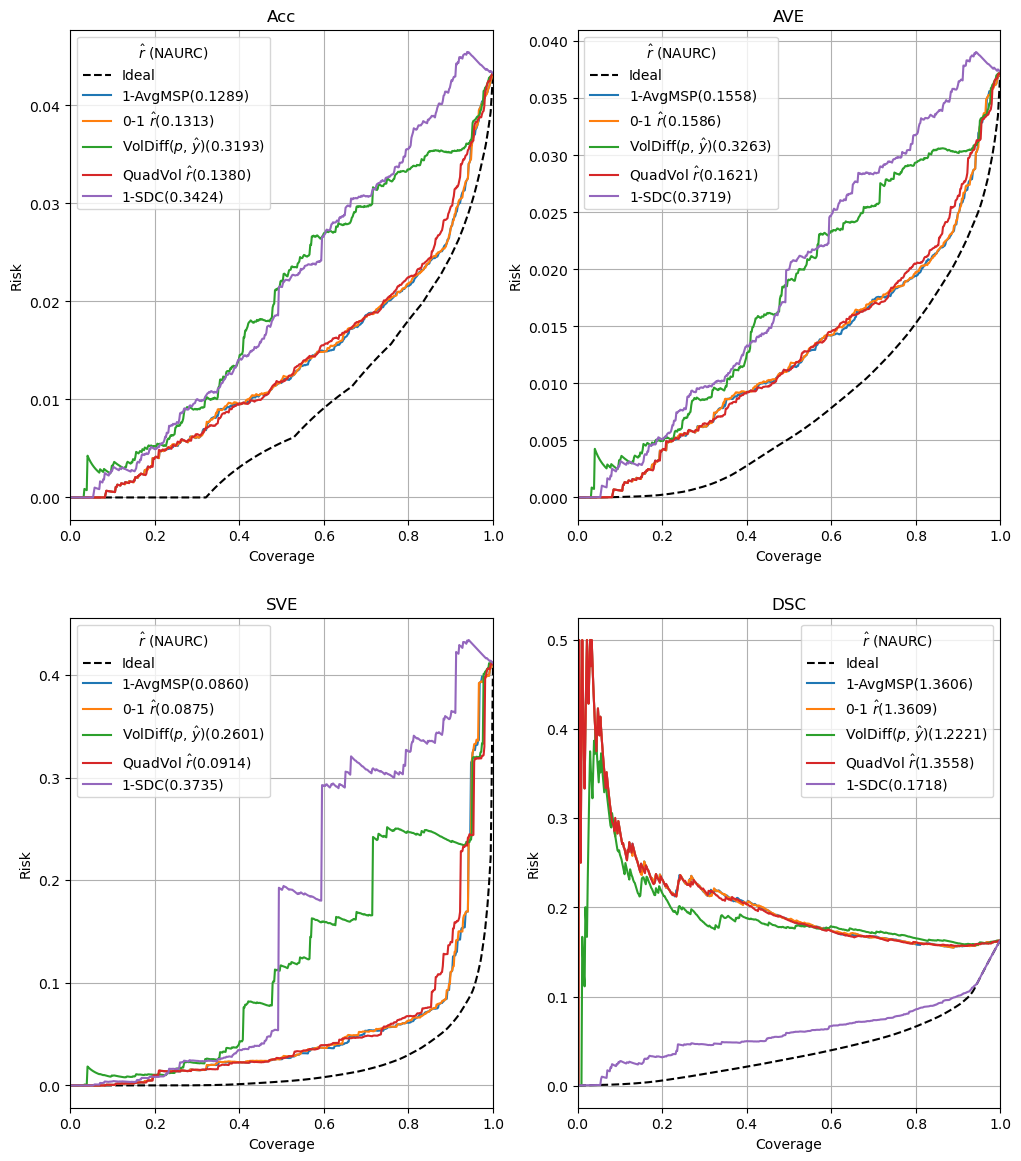

In [13]:
losses = {
    "Acc": lambda y, y_hat: 1 - (y == (y_hat > 0.5)).mean(),
    "AVE": lambda y, y_hat: np.abs(y.sum(dtype=float) - y_hat.sum(dtype=float)) / (y.shape[0] * y.shape[1]),
    "SVE": lambda y, y_hat: (y.sum(dtype=float) - y_hat.sum(dtype=float))**2 / (y.shape[0] * y.shape[1]),
    "DSC": lambda y, y_hat: 1 - 2 * (y * y_hat).sum() / (y.sum() + y_hat.sum()+1e-3)
}

fig, axs = plt.subplots(int(len(losses)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(losses)/2 + 0.5))

for ax, (loss_name, loss_fn) in zip(axs.flatten(), losses.items()):
    loss_values = np.array([loss_fn(y, y_hat) for y, y_hat in zip(Y, hatY)])

    ## IDEAL
    risks, coverages = rc_curve_(loss_values, -loss_values)
    ax.plot(coverages, risks, '--', c='black', label="Ideal")

    ideal_aurc = auc(coverages, risks)
    random_aurc = np.max(risks)

    ## MSP
    plot_rc_curve(ax, get_avg_msp_rhat(h, dummy_hatPyi), loss_values, f"1-AvgMSP", ideal_aurc, random_aurc)

    # ## 01 RISK
    plot_rc_curve(ax, get_01_rhat(h, dummy_hatPyi), loss_values, r"0-1 $\hat{r}$", ideal_aurc, random_aurc)

    # ## Soft Volume Difference
    plot_rc_curve(ax, get_softvoldiff(h, dummy_hatPyi), loss_values, r"VolDiff($p$, $\hat{y}$)", ideal_aurc, random_aurc)

    # ## Quad volume difference
    plot_rc_curve(ax, get_quadvoldiff_rhat(h, dummy_hatPyi), loss_values, r"QuadVol $\hat{r}$", ideal_aurc, random_aurc)

    # ## SDC
    plot_rc_curve(ax, get_softdice_risk(h, dummy_hatPyi), loss_values, r"1-SDC", ideal_aurc, random_aurc)

    # ylim = plt.ylim()
    # plt.ylim(0, ylim[1])
    ax.set_xlim(0, 1)
    ax.grid()
    ax.legend(title=r"$\hat{r}$ (NAURC)")
    ax.set_title(loss_name)
    ax.set_ylabel("Risk")
    ax.set_xlabel("Coverage")

## 4²

In [14]:
Y = [resize(y[0], (4,4), order=0, anti_aliasing=False) for y in Y_og]
hatY = [resize(y_hat[0], (4,4), order=0, anti_aliasing=False) for y_hat in hatY_og]

dummy_Py = np.eye(len(Y))
dummy_Pyi = Y
dummy_hatPyi = hatY

h = lambda x: hatY[x] > 0.5

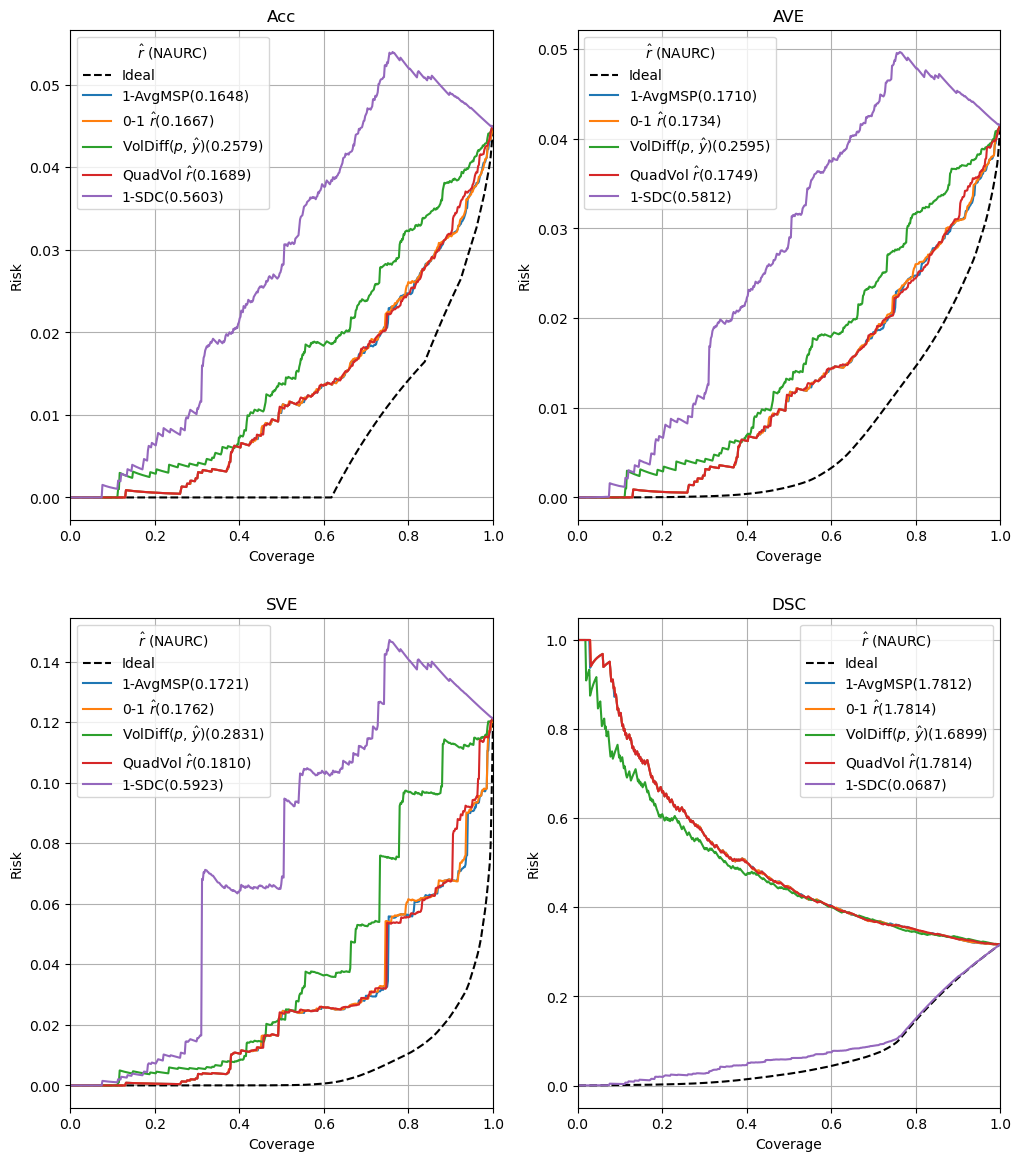

In [15]:
losses = {
    "Acc": lambda y, y_hat: 1 - (y == (y_hat > 0.5)).mean(),
    "AVE": lambda y, y_hat: np.abs(y.sum(dtype=float) - y_hat.sum(dtype=float)) / (y.shape[0] * y.shape[1]),
    "SVE": lambda y, y_hat: (y.sum(dtype=float) - y_hat.sum(dtype=float))**2 / (y.shape[0] * y.shape[1]),
    "DSC": lambda y, y_hat: 1 - 2 * (y * y_hat).sum() / (y.sum() + y_hat.sum()+1e-3)
}

fig, axs = plt.subplots(int(len(losses)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(losses)/2 + 0.5))

for ax, (loss_name, loss_fn) in zip(axs.flatten(), losses.items()):
    loss_values = np.array([loss_fn(y, y_hat) for y, y_hat in zip(Y, hatY)])

    ## IDEAL
    risks, coverages = rc_curve_(loss_values, -loss_values)
    ax.plot(coverages, risks, '--', c='black', label="Ideal")

    ideal_aurc = auc(coverages, risks)
    random_aurc = np.max(risks)

    ## MSP
    plot_rc_curve(ax, get_avg_msp_rhat(h, dummy_hatPyi), loss_values, f"1-AvgMSP", ideal_aurc, random_aurc)

    # ## 01 RISK
    plot_rc_curve(ax, get_01_rhat(h, dummy_hatPyi), loss_values, r"0-1 $\hat{r}$", ideal_aurc, random_aurc)

    # ## Soft Volume Difference
    plot_rc_curve(ax, get_softvoldiff(h, dummy_hatPyi), loss_values, r"VolDiff($p$, $\hat{y}$)", ideal_aurc, random_aurc)

    # ## Quad volume difference
    plot_rc_curve(ax, get_quadvoldiff_rhat(h, dummy_hatPyi), loss_values, r"QuadVol $\hat{r}$", ideal_aurc, random_aurc)

    # ## SDC
    plot_rc_curve(ax, get_softdice_risk(h, dummy_hatPyi), loss_values, r"1-SDC", ideal_aurc, random_aurc)

    # ylim = plt.ylim()
    # plt.ylim(0, ylim[1])
    ax.set_xlim(0, 1)
    ax.grid()
    ax.legend(title=r"$\hat{r}$ (NAURC)")
    ax.set_title(loss_name)
    ax.set_ylabel("Risk")
    ax.set_xlabel("Coverage")

## Size bias

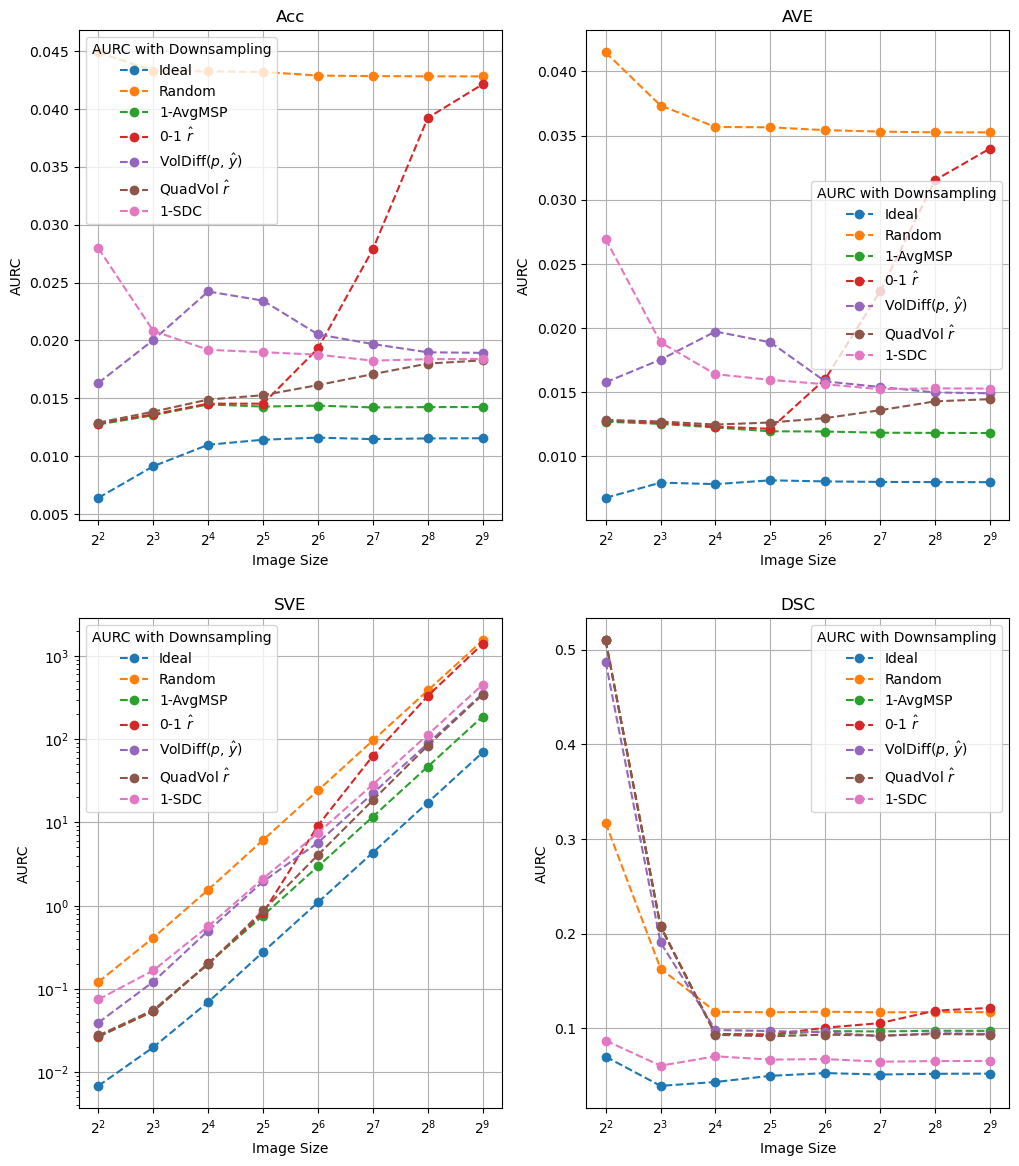

In [20]:
losses = {
    "Acc": lambda y, y_hat: 1 - (y == (y_hat > 0.5)).mean(),
    "AVE": lambda y, y_hat: np.abs(y.sum(dtype=float) - y_hat.sum(dtype=float)) / (y.shape[0] * y.shape[1]),
    "SVE": lambda y, y_hat: (y.sum(dtype=float) - y_hat.sum(dtype=float))**2 / (y.shape[0] * y.shape[1]),
    "DSC": lambda y, y_hat: 1 - 2 * (y * y_hat).sum() / (y.sum() + y_hat.sum()+1e-3)
}

sizes = [4, 8, 16, 32, 64, 128, 256, 512]

fig, axs = plt.subplots(int(len(losses)/2 + 0.5), 2, squeeze=True)
fig.set_size_inches(2*6, 7*int(len(losses)/2 + 0.5))

for ax, (loss_name, loss_fn) in zip(axs.flatten(), losses.items()):
    aurcs = {
        "Ideal": [],
        "Random": [],
        f"1-AvgMSP": [],
        r"0-1 $\hat{r}$": [],
        r"VolDiff($p$, $\hat{y}$)": [],
        r"QuadVol $\hat{r}$": [],
        r"1-SDC": [],
    }

    for size in sizes:
        Y = [resize(y[0], (size,size), order=0, anti_aliasing=False) for y in Y_og]
        hatY = [resize(y_hat[0], (size,size), order=0, anti_aliasing=False) for y_hat in hatY_og]

        dummy_Py = np.eye(len(Y))
        dummy_Pyi = Y
        dummy_hatPyi = hatY

        h = lambda x: hatY[x] > 0.5

        loss_values = np.array([loss_fn(y, y_hat) for y, y_hat in zip(Y, hatY)])

        ## IDEAL
        risks, coverages = rc_curve_(loss_values, -loss_values)

        aurcs["Ideal"].append(auc(coverages, risks))
        aurcs["Random"].append(np.max(risks))

        ## MSP
        r_hat = get_avg_msp_rhat(h, dummy_hatPyi)
        risks, coverages = rc_curve_(loss_values, -np.array([r_hat(x) for x in range(len(loss_values))]))
        aurcs["1-AvgMSP"].append(auc(coverages, risks))

        ## 01 RISK
        r_hat = get_01_rhat(h, dummy_hatPyi)
        risks, coverages = rc_curve_(loss_values, -np.array([r_hat(x) for x in range(len(loss_values))]))
        aurcs[r"0-1 $\hat{r}$"].append(auc(coverages, risks))

        ## Soft Volume Difference
        r_hat = get_softvoldiff(h, dummy_hatPyi)
        risks, coverages = rc_curve_(loss_values, -np.array([r_hat(x) for x in range(len(loss_values))]))
        aurcs[r"VolDiff($p$, $\hat{y}$)"].append(auc(coverages, risks))

        ## Quad volume difference
        r_hat = get_quadvoldiff_rhat(h, dummy_hatPyi)
        risks, coverages = rc_curve_(loss_values, -np.array([r_hat(x) for x in range(len(loss_values))]))
        aurcs[r"QuadVol $\hat{r}$"].append(auc(coverages, risks))

        ## SDC
        r_hat = get_softdice_risk(h, dummy_hatPyi)
        risks, coverages = rc_curve_(loss_values, -np.array([r_hat(x) for x in range(len(loss_values))]))
        aurcs[r"1-SDC"].append(auc(coverages, risks))

    for k, v in aurcs.items():
        ax.plot(sizes, v, '--o', label=k)

    if loss_name == "SVE":
        ax.set_yscale('log')

    # ax.set_xlim(0, 1)
    ax.set_xscale('log', base=2)
    ax.grid()
    ax.legend(title=r"AURC with Downsampling")
    ax.set_title(loss_name)
    ax.set_ylabel("AURC")
    ax.set_xlabel("Image Size")

fig.show()

## Comments

This experiment is almost a sanity check. The only interesting empirical result is that there does not seem to be a "silver bullet" in terms of confidence estimator. However, this experiment confirms our theoretical results.